In [1]:
pip install transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [2]:
#libraries
import spacy
import requests
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from transformers import pipeline
from collections import defaultdict

**Load a Dickens Text**

In [3]:
# barnaby rudge
url = "https://www.gutenberg.org/cache/epub/917/pg917.txt"
text = requests.get(url).text

**Preprocess & Load into spaCy**

In [4]:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 9000000000000000000

doc = nlp(text[3000:])

**Extract Sentences with Mental State Verbs**

In [5]:
theory_of_mind_verbs = [
    "think", "believe", "know", "wonder", "suppose", "realize",
    "realise","imagine", "guess", "doubt", "feel", "consider",
    "hope","wish", "suspect", "predict", "expect", "assume", "fear"
]

matching_sentences = []

for sent in doc.sents:
    if any(token.lemma_ in theory_of_mind_verbs for token in sent):
        matching_sentences.append(sent.text)

**Count Mental State Verb Frequency**

In [6]:
verb_counts = Counter()

for sent in doc.sents:
    for token in sent:
        if token.lemma_ in theory_of_mind_verbs:
            verb_counts[token.lemma_] += 1

print(verb_counts.most_common())

[('know', 717), ('think', 356), ('hope', 161), ('feel', 134), ('doubt', 99), ('believe', 98), ('wish', 96), ('fear', 91), ('suppose', 88), ('wonder', 83), ('consider', 58), ('expect', 54), ('assume', 17), ('suspect', 11), ('guess', 10), ('imagine', 8), ('predict', 4), ('realise', 1)]


**Visualise Frequency Over Time (Chunk-Based)**

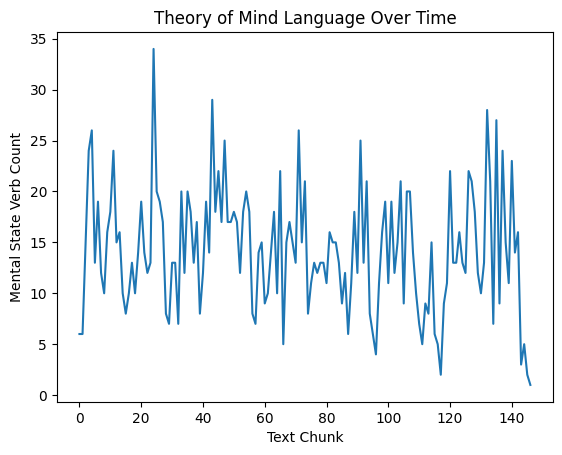

In [7]:
chunk_size = 10000  # adjustments can be made
chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
counts_over_time = []

for chunk in chunks:
    doc = nlp(chunk)
    count = sum(1 for token in doc if token.lemma_ in theory_of_mind_verbs)
    counts_over_time.append(count)

plt.plot(counts_over_time)
plt.xlabel("Text Chunk")
plt.ylabel("Mental State Verb Count")
plt.title("Theory of Mind Language Over Time")
plt.show()

**Track Character Co-occurrence**
To find which characters are associated with mental states.

In [8]:
characters = [
    "Barnaby Rudge", "Barnaby", "Rudge",
    "Gabriel Varden", "Mr. Varden", "The locksmith",
    "Dolly Varden", "Dolly", "Miss Varden",
    "Martha Varden", "Mrs. Varden",
    "Joe Willet", "Joe", "Joseph Willet",
    "John Willet", "Mr. Willet", "Landlord", "The landlord of the Maypole",
    "Geoffrey Haredale", "Mr. Haredale", "Mr. Geoffrey Haredale",
    "Emma Haredale", "Emma", "Miss Haredale",
    "Edward Chester", "Edward", "Ned Chester",
    "Sir John Chester", "Sir John", "Mr. Chester",
    "Hugh", "The ostler", "The groom",
    "Lord George Gordon", "Lord Gordon",
    "Simon Tappertit", "Mr. Tappertit", "Sim",
    "Mrs. Rudge", "Mary Rudge", "Barnaby’s mother",
    "Mr. Gashford", "Gashford",
    "Mr. Dennis", "Dennis", "The hangman",
    "Tom Cobb", "Cobb",
    "Miggs", "Miss Miggs",
    "Mr. Solomon Daisy", "Solomon Daisy", "Mr. Daisy",
    "The Stranger", "Rudge Sr.", "Barnaby’s father", "The murderer",
    "John Grueby", "Grueby",
    "The Hangman",  # refers to Dennis
    "The 'Prentice",  # refers to Simon Tappertit
    "The Apprentice",  # alternate for Simon
    "The Maypole",  # tavern, often personified
    "The Gentleman",  # used for various characters in vague reference
    "The Mob Leader",  # often refers to Hugh
]



character_mentalization = {name: 0 for name in characters}

for sent in matching_sentences:
    for name in characters:
        if name in sent:
            character_mentalization[name] += 1

print(character_mentalization)

{'Barnaby Rudge': 3, 'Barnaby': 76, 'Rudge': 4, 'Gabriel Varden': 2, 'Mr. Varden': 0, 'The locksmith': 5, 'Dolly Varden': 2, 'Dolly': 80, 'Miss Varden': 1, 'Martha Varden': 0, 'Mrs. Varden': 0, 'Joe Willet': 0, 'Joe': 65, 'Joseph Willet': 3, 'John Willet': 13, 'Mr. Willet': 0, 'Landlord': 0, 'The landlord of the Maypole': 0, 'Geoffrey Haredale': 1, 'Mr. Haredale': 0, 'Mr. Geoffrey Haredale': 0, 'Emma Haredale': 2, 'Emma': 21, 'Miss Haredale': 11, 'Edward Chester': 2, 'Edward': 25, 'Ned Chester': 0, 'Sir John Chester': 3, 'Sir John': 16, 'Mr. Chester': 0, 'Hugh': 89, 'The ostler': 0, 'The groom': 0, 'Lord George Gordon': 4, 'Lord Gordon': 0, 'Simon Tappertit': 5, 'Mr. Tappertit': 0, 'Sim': 27, 'Mrs. Rudge': 0, 'Mary Rudge': 0, 'Barnaby’s mother': 1, 'Mr. Gashford': 0, 'Gashford': 36, 'Mr. Dennis': 0, 'Dennis': 42, 'The hangman': 0, 'Tom Cobb': 3, 'Cobb': 8, 'Miggs': 49, 'Miss Miggs': 12, 'Mr. Solomon Daisy': 0, 'Solomon Daisy': 5, 'Mr. Daisy': 0, 'The Stranger': 0, 'Rudge Sr.': 0, 'Barn



---



**BERT-Based Emotion Detection**

**Load Pretrained Emotion Model**

In [9]:
# load emotion classifier pipeline
emotion_pipeline = pipeline("text-classification",
                            model="j-hartmann/emotion-english-distilroberta-base",
                            return_all_scores=True)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


**Run Emotion Detection on the Whole Book**

In [14]:
def chunk_text(text, size=1000):
    words = text.split()
    return [' '.join(words[i:i+size]) for i in range(0, len(words), size)]

chunks = chunk_text(text[3000:], size=15000)

emotion_scores = []

for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        scores_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(scores_dict)
    except:
        continue

**Convert to DataFrame & Plot Emotion Arcs**

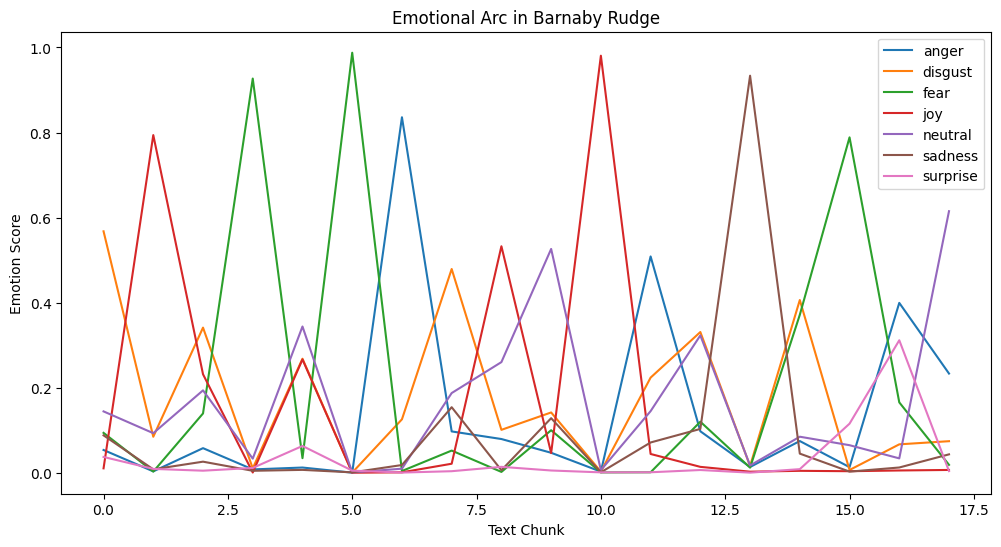

In [15]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)

plt.legend()
plt.title("Emotional Arc in Barnaby Rudge")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.show()

Total Emotions

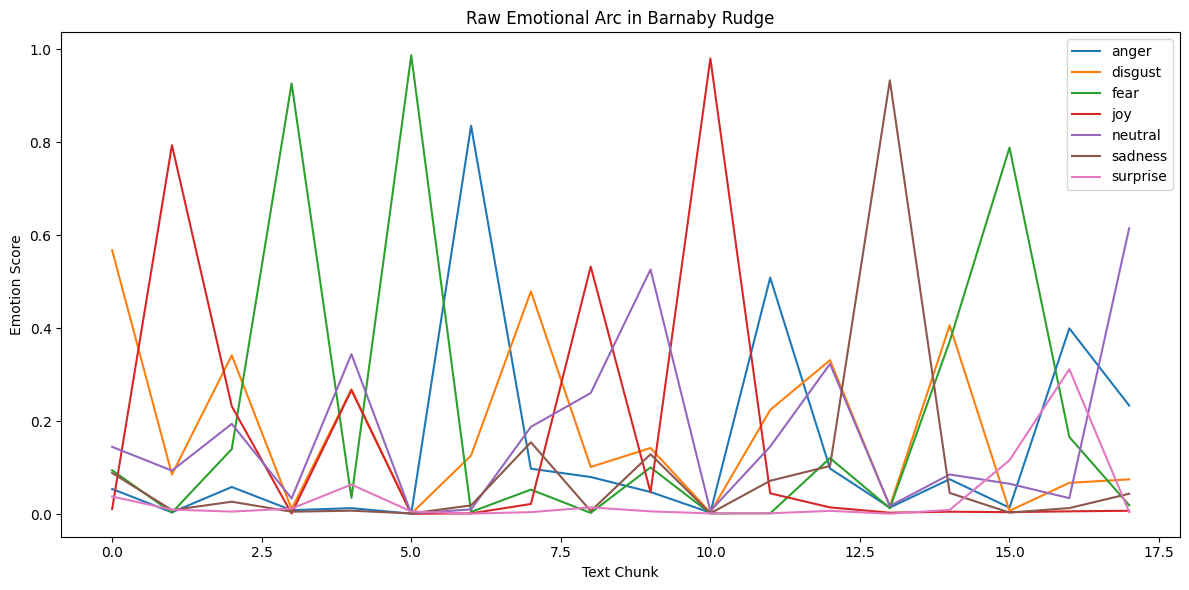

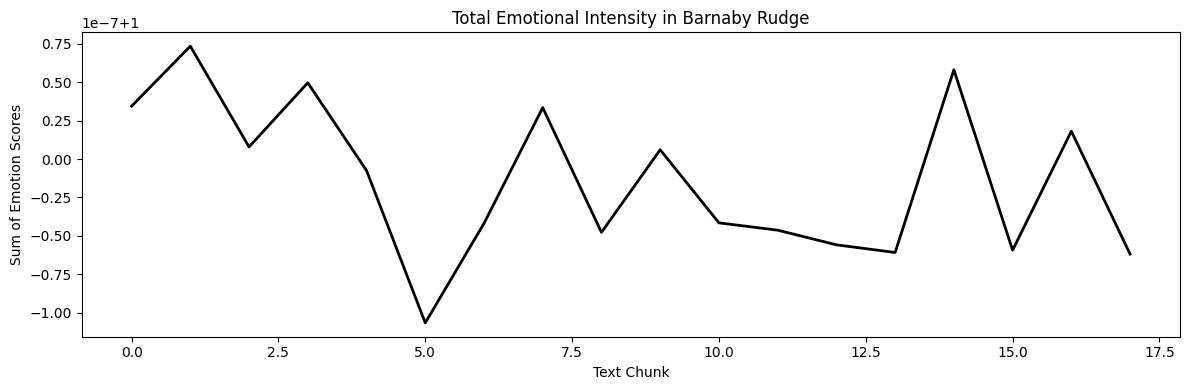

In [16]:
# Analyze emotions in each chunk WITHOUT normalization
emotion_scores = []
for chunk in chunks:
    try:
        scores = emotion_pipeline(chunk[:512])[0]  # limit to BERT's max token count
        score_dict = {s["label"]: s["score"] for s in scores}
        emotion_scores.append(score_dict)
    except Exception as e:
        print(f"Error: {e}")
        continue

# Convert to DataFrame
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Plot individual emotions
plt.figure(figsize=(12, 6))
for emotion in df.columns:
    plt.plot(df[emotion], label=emotion)
plt.legend()
plt.title("Raw Emotional Arc in Barnaby Rudge")
plt.xlabel("Text Chunk")
plt.ylabel("Emotion Score")
plt.tight_layout()
plt.show()

# ➕ Now sum all raw emotions at each chunk
df["Total_Emotion"] = df.sum(axis=1)

# Plot total emotional intensity
plt.figure(figsize=(12, 4))
plt.plot(df["Total_Emotion"], color="black", linewidth=2)
plt.title("Total Emotional Intensity in Barnaby Rudge")
plt.xlabel("Text Chunk")
plt.ylabel("Sum of Emotion Scores")
plt.tight_layout()
plt.show()

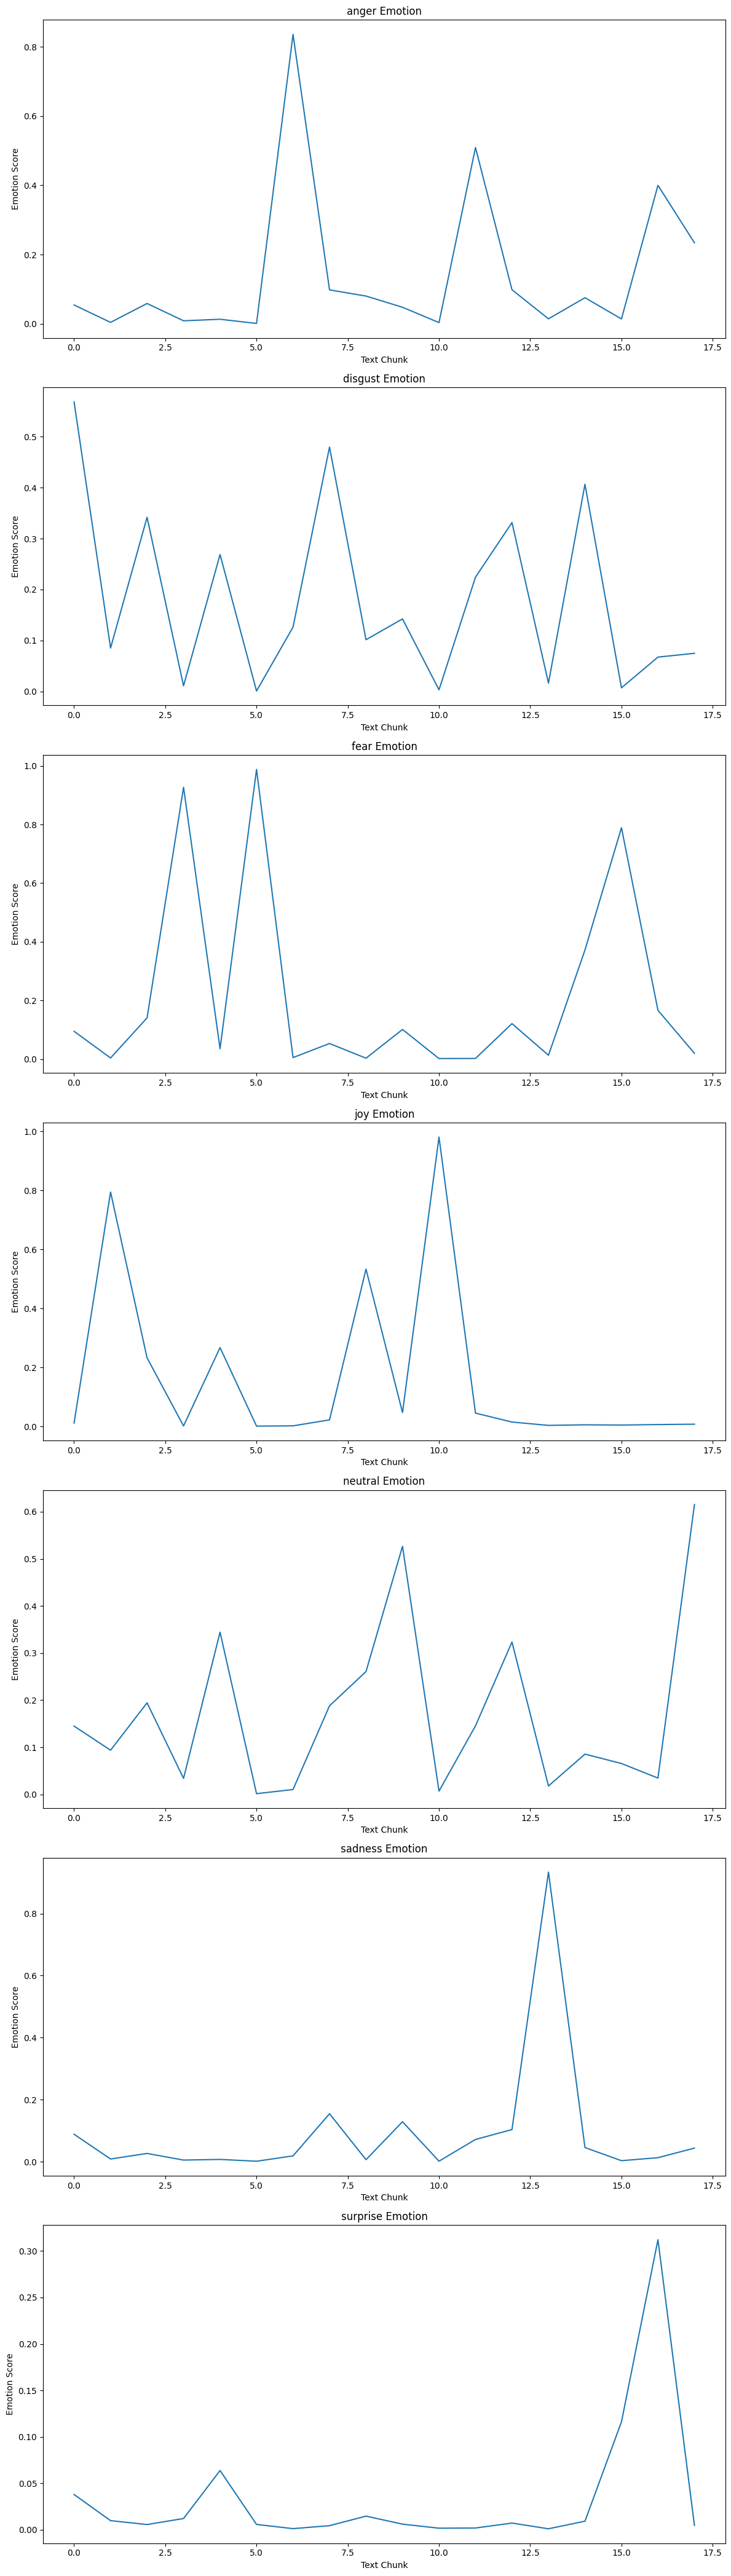

In [17]:
df = pd.DataFrame(emotion_scores)
df.fillna(0, inplace=True)

# Determine the number of emotions
num_emotions = len(df.columns)

# Set up subplots: one for each emotion
fig, axes = plt.subplots(num_emotions, 1, figsize=(12, 6 * num_emotions))

# If there's only one emotion, axes is not an array, so we handle it separately
if num_emotions == 1:
    axes = [axes]

for i, emotion in enumerate(df.columns):
    axes[i].plot(df[emotion])
    axes[i].set_title(f"{emotion} Emotion")
    axes[i].set_xlabel("Text Chunk")
    axes[i].set_ylabel("Emotion Score")

plt.tight_layout()
plt.show()